In [45]:
import pandas as pd
import matplotlib.pyplot as plt
analysis = pd.read_csv("../data/raw/spotify_metrics_2018-2025.csv")
analysis.head()

,year,maus_millions,premium_subscribers_millions,ad_supported_maus_millions,premium_revenue_millions,ad_supported_revenue_millions,total_revenue_millions,premium_gross_margin,ad_supported_gross_margin,total_gross_margin,operating_income_millions
0,2025,751,290,476,15350,1836,17186,34%,18%,32%,2198
1,2024,675,263,425,13819,1854,15673,33%,12%,30%,1365
2,2023,602,236,379,11566,1681,13247,29%,4%,26%,-446
3,2022,489,205,295,10251,1476,11727,28%,2%,25%,-659
4,2021,406,180,236,8460,1208,9668,29%,10%,27%,94


# Analyses
## Revenue grew, but profitability depends on margin expansion

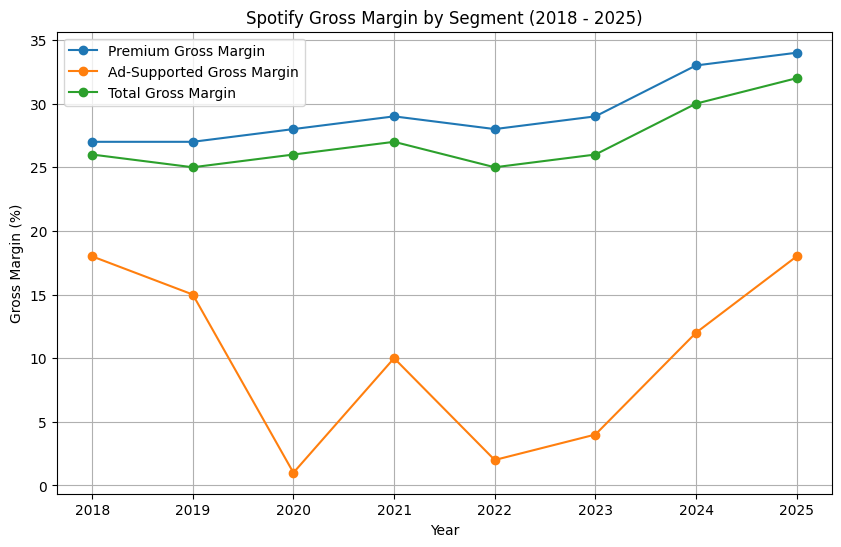

In [46]:
# Cleaning percentages for plotting
margin_cols = [
    "premium_gross_margin",
    "ad_supported_gross_margin",
    "total_gross_margin"
]
for col in margin_cols:
    analysis[col] = analysis[col].str.replace("%", "").astype(float)


plt.figure(figsize=(10, 6))
plt.plot(analysis["year"], analysis["premium_gross_margin"], marker="o", label="Premium Gross Margin")
plt.plot(analysis["year"], analysis["ad_supported_gross_margin"], marker="o", label="Ad-Supported Gross Margin")
plt.plot(analysis["year"], analysis["total_gross_margin"], marker="o", label="Total Gross Margin")
plt.title("Spotify Gross Margin by Segment (2018 - 2025)")
plt.xlabel("Year")
plt.ylabel("Gross Margin (%)")
plt.xticks(analysis["year"])
plt.legend()
plt.grid(True)
plt.savefig("../visuals/analysis/spotify_gross_margin_by_segment_2018_2025.png", bbox_inches="tight", dpi=300)
plt.show()

## Revenue growth did not translate proportionally into operating income

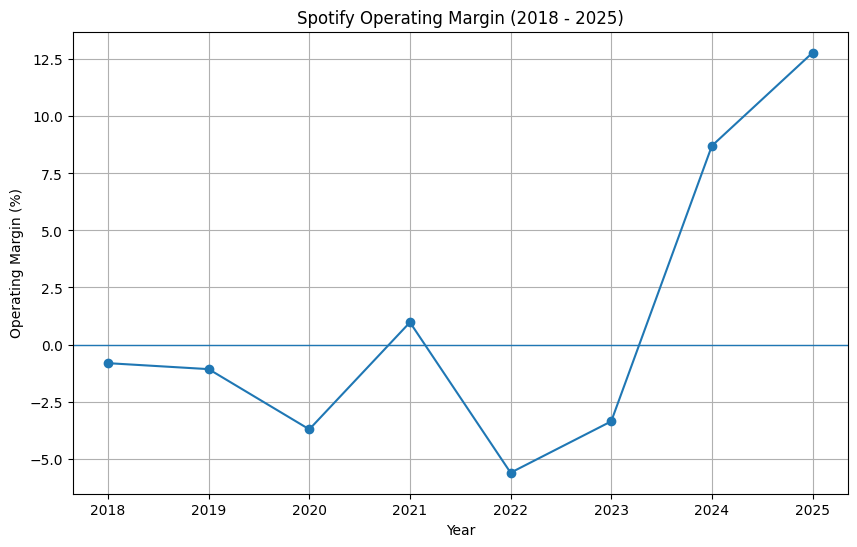

In [47]:
# Calculating operating margin
analysis["operating_margin"] = (analysis["operating_income_millions"] / analysis["total_revenue_millions"] * 100)

plt.figure(figsize=(10, 6))
plt.plot(analysis["year"], analysis["operating_margin"], marker="o")
plt.axhline(0, linewidth=1)
plt.title("Spotify Operating Margin (2018 - 2025)")
plt.xlabel("Year")
plt.ylabel("Operating Margin (%)")
plt.xticks(analysis["year"])
plt.grid(True)
plt.savefig("../visuals/analysis/spotify_operating_margin_2018_2025.png", bbox_inches="tight", dpi=300)
plt.show()

## Operating expenses explain the gap between gross profit and operating income

In [48]:
analysis = pd.read_csv("../data/raw/spotify_metrics_2018-2025.csv")
expenses = pd.read_csv("../data/raw/spotify_expenses.csv")

expense_cols = ["cost_of_revenue_millions", "research_and_development_millions", "sales_and_marketing_millions", "general_and_administrative_millions", "total_operating_expenses_millions"]
for col in expense_cols:
    expenses[col] = expenses[col].astype(str).str.replace(",", "").astype(int)

# Merged expenses with main analysis due to obtaining the operating expenses data after initial analysis
analysis = analysis.merge(expenses, on="year", how="left")

# Adding gross profit column to analyze the gap between gross profit and operating income
analysis["total_gross_margin"] = analysis["total_gross_margin"].astype(
    str).str.replace("%", "").astype(float)
analysis["gross_profit_millions"] = analysis["total_revenue_millions"] * \
analysis["total_gross_margin"] / 100

### Operating expenses by category

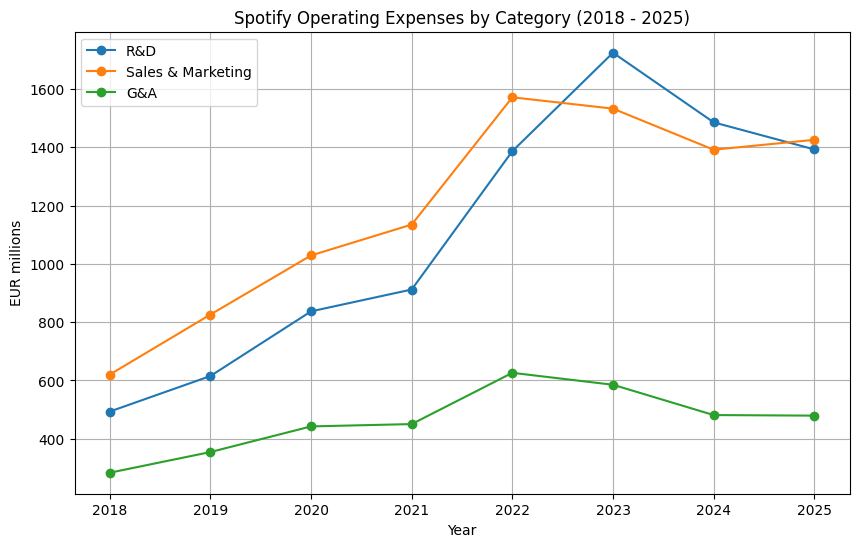

In [49]:
plt.figure(figsize=(10, 6))
plt.plot(analysis["year"], analysis["research_and_development_millions"], marker="o", label="R&D")
plt.plot(analysis["year"], analysis["sales_and_marketing_millions"], marker="o", label="Sales & Marketing")
plt.plot(analysis["year"], analysis["general_and_administrative_millions"], marker="o", label="G&A")
plt.title("Spotify Operating Expenses by Category (2018 - 2025)")
plt.xlabel("Year")
plt.ylabel("EUR millions")
plt.xticks(analysis["year"])
plt.legend()
plt.grid(True)
plt.savefig("../visuals/analysis/spotify_operating_expenses_by_category_2018_2025.png", bbox_inches="tight", dpi=300)
plt.show()

### Gross profit vs Operating expenses vs Operating income

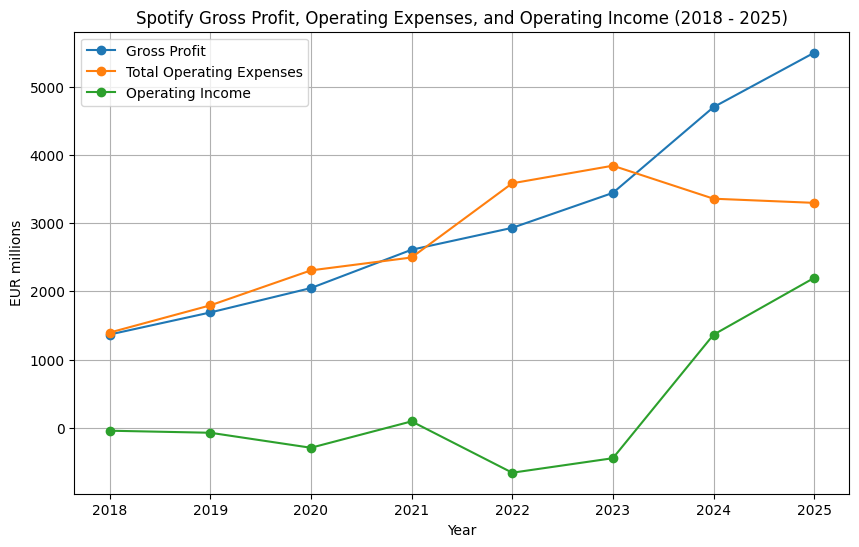

In [50]:
plt.figure(figsize=(10, 6))
plt.plot(analysis["year"], analysis["gross_profit_millions"], marker="o", label="Gross Profit")
plt.plot(analysis["year"], analysis["total_operating_expenses_millions"], marker="o", label="Total Operating Expenses")
plt.plot(analysis["year"], analysis["operating_income_millions"], marker="o", label="Operating Income")
plt.title(
    "Spotify Gross Profit, Operating Expenses, and Operating Income (2018 - 2025)")
plt.xlabel("Year")
plt.ylabel("EUR millions")
plt.xticks(analysis["year"])
plt.legend()
plt.grid(True)
plt.savefig("../visuals/analysis/spotify_gross_profit_opex_operating_income_2018_2025.png", bbox_inches="tight", dpi=300)
plt.show()